# **AML LAB**

## **Experiment 7**

##Anomaly Detection: Implement an anomaly detection system for detecting outliers in data (e.g., fraud detection) and perform comparative analysis. (Isolation Forest, Local Outlier Factor, One-Class SVM)


###1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

###2. Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Applied_ML_Lab/Lab_8/anomaly_detection_dataset_500_samples.csv")

df.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


###3. Data Understanding

In [ ]:
df.info()
df.isnull().sum()

# Check class distribution (if label exists)
df['Anomaly_Label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature_1      500 non-null    float64
 1   Feature_2      500 non-null    float64
 2   Anomaly_Label  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


,count
Anomaly_Label,
0,470
1,30


###4. Handle Missing Values

In [ ]:
df = df.dropna()

###5. Feature-Target Split

In [ ]:
X = df.drop('Anomaly_Label', axis=1)
y = df['Anomaly_Label']

###6. Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###7. Initialize Anomaly Detection Models

In [ ]:
models = {
    "Isolation Forest": IsolationForest(contamination=0.1, random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(contamination=0.1),
    "One-Class SVM": OneClassSVM(nu=0.1)
}

###8. Train and Predict

In [ ]:
results = {}

for name, model in models.items():

    if name == "Local Outlier Factor":
        y_pred = model.fit_predict(X_scaled)
    else:
        model.fit(X_scaled)
        y_pred = model.predict(X_scaled)

    # Convert predictions:
    # -1 → anomaly
    #  1 → normal
    y_pred = np.where(y_pred == -1, 1, 0)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    results[name] = [accuracy, precision, recall, f1]

    print("\nModel:", name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))


Model: Isolation Forest
Accuracy: 0.96
Precision: 0.6
Recall: 1.0
F1-Score: 0.75
Confusion Matrix:
 [[450  20]
 [  0  30]]

Model: Local Outlier Factor
Accuracy: 0.844
Precision: 0.02
Recall: 0.03333333333333333
F1-Score: 0.025
Confusion Matrix:
 [[421  49]
 [ 29   1]]

Model: One-Class SVM
Accuracy: 0.904
Precision: 0.32
Recall: 0.5333333333333333
F1-Score: 0.4
Confusion Matrix:
 [[436  34]
 [ 14  16]]


###9. Comparative Performance Table

In [ ]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df

,Isolation Forest,Local Outlier Factor,One-Class SVM
Accuracy,0.96,0.844000,0.904000
Precision,0.60,0.020000,0.320000
Recall,1.00,0.033333,0.533333
F1-Score,0.75,0.025000,0.400000


###10. Visualization: Model Comparison

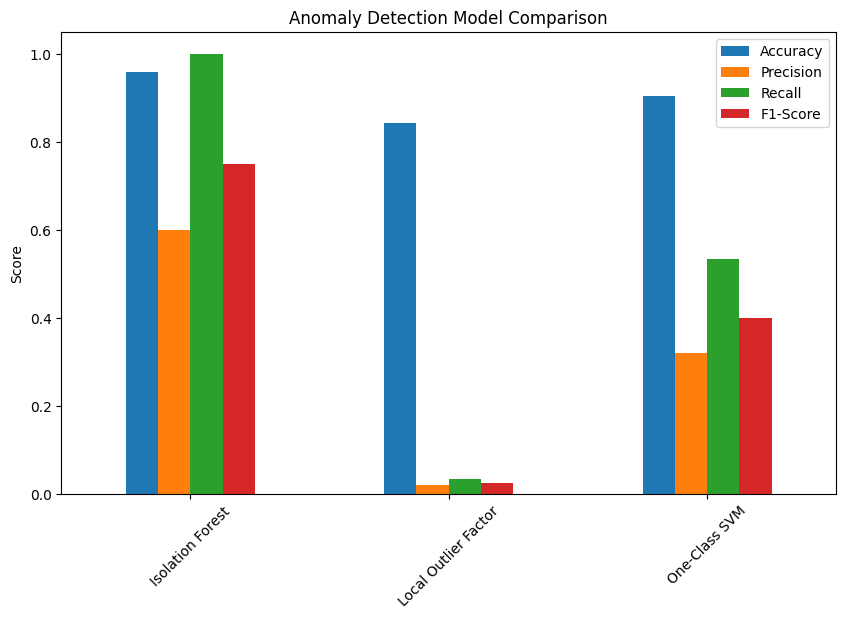

In [ ]:
results_df.T.plot(kind='bar', figsize=(10,6))
plt.title("Anomaly Detection Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()